# Semana 4: Word Embeddings: Word2Vec y GloVe
## Notebook Conceptual (NB1) – Entrenando Embeddings desde Cero

**Propósito:** Comprender la diferencia entre representaciones densas y dispersas, entrenar embeddings y explorar sus propiedades semánticas.

**Docente:** Carlos César Sánchez Coronel

**Objetivos de aprendizaje:**
- Entender las arquitecturas Skip-gram y CBOW.
- Entrenar Word2Vec con gensim sobre un corpus pequeño.
- Visualizar embeddings con PCA y t-SNE.
- Probar analogías semánticas.
- Cargar embeddings pre-entrenados de GloVe y comparar cobertura.

---

## 0. Configuración Inicial

Importamos las librerías necesarias y descargamos recursos.

In [2]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.7 MB/s eta 0:00:00


In [3]:
# Importamos librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Gensim para Word2Vec
import gensim
from gensim.models import Word2Vec, KeyedVectors

# Scikit-learn para visualización
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# NLTK para tokenización
import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize

# Para descargar GloVe (si es necesario)
import urllib.request
import zipfile
import os

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Semilla
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Corpus Pequeño para Entrenamiento

Creamos un corpus pequeño con oraciones que contengan relaciones semánticas y sintácticas para explorar.

In [4]:
# Definimos un corpus pequeño
corpus = [
    "el rey gobierna el reino",
    "la reina gobierna el reino",
    "el hombre camina por la calle",
    "la mujer camina por la calle",
    "los niños juegan en el parque",
    "las niñas juegan en el parque",
    "el perro persigue al gato",
    "el gato persigue al ratón",
    "madrid es la capital de españa",
    "parís es la capital de francia",
    "roma es la capital de italia",
    "berlín es la capital de alemania"
]

print("=== CORPUS ===")
for i, sentence in enumerate(corpus):
    print(f"{i+1}. {sentence}")

=== CORPUS ===
1. el rey gobierna el reino
2. la reina gobierna el reino
3. el hombre camina por la calle
4. la mujer camina por la calle
5. los niños juegan en el parque
6. las niñas juegan en el parque
7. el perro persigue al gato
8. el gato persigue al ratón
9. madrid es la capital de españa
10. parís es la capital de francia
11. roma es la capital de italia
12. berlín es la capital de alemania


### 1.1. Tokenización del corpus

Tokenizamos cada oración para obtener listas de palabras, que es el formato que espera gensim.

In [6]:
import nltk
nltk.download('punkt_tab', quiet=True)

# Tokenizamos cada oración
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

print("Corpus tokenizado:")
for i, tokens in enumerate(tokenized_corpus):
    print(f"{i+1}. {tokens}")

Corpus tokenizado:
1. ['el', 'rey', 'gobierna', 'el', 'reino']
2. ['la', 'reina', 'gobierna', 'el', 'reino']
3. ['el', 'hombre', 'camina', 'por', 'la', 'calle']
4. ['la', 'mujer', 'camina', 'por', 'la', 'calle']
5. ['los', 'niños', 'juegan', 'en', 'el', 'parque']
6. ['las', 'niñas', 'juegan', 'en', 'el', 'parque']
7. ['el', 'perro', 'persigue', 'al', 'gato']
8. ['el', 'gato', 'persigue', 'al', 'ratón']
9. ['madrid', 'es', 'la', 'capital', 'de', 'españa']
10. ['parís', 'es', 'la', 'capital', 'de', 'francia']
11. ['roma', 'es', 'la', 'capital', 'de', 'italia']
12. ['berlín', 'es', 'la', 'capital', 'de', 'alemania']


---
## 2. Arquitecturas: CBOW y Skip-gram

### 2.1. CBOW (Continuous Bag of Words)

CBOW predice la palabra objetivo a partir de su contexto (palabras circundantes).

**Ejemplo:** Contexto: ["el", "gato", "al", "ratón"] → Predicción: "persigue"

**Ventajas:** Más rápido de entrenar, mejor con palabras frecuentes.

### 2.2. Skip-gram

Skip-gram predice las palabras de contexto a partir de la palabra objetivo.

**Ejemplo:** Palabra objetivo: "persigue" → Predicciones: ["el", "gato", "al", "ratón"]

**Ventajas:** Mejor con palabras poco frecuentes, captura mejor relaciones semánticas.

**Diagrama conceptual:**

```
CBOW:    [contexto] -> (promedio) -> [objetivo]
Skip-gram: [objetivo] -> (embeddings) -> [contexto]
```

---
## 3. Entrenamiento de Word2Vec con Gensim

Entrenamos dos modelos: uno con CBOW y otro con Skip-gram para comparar.

In [7]:
# Entrenamos modelo CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,      # dimensión de los embeddings
    window=3,            # ventana de contexto
    min_count=1,         # incluir todas las palabras
    workers=1,           # para reproducibilidad
    sg=0,                # 0 = CBOW
    seed=42
)

# Entrenamos modelo Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    sg=1,                # 1 = Skip-gram
    seed=42
)

print("Modelos entrenados.")
print(f"Vocabulario CBOW: {len(model_cbow.wv.key_to_index)} palabras")
print(f"Vocabulario Skip-gram: {len(model_skipgram.wv.key_to_index)} palabras")

Modelos entrenados.
Vocabulario CBOW: 34 palabras
Vocabulario Skip-gram: 34 palabras


### 3.1. Exploración de los embeddings

Obtenemos el vector de una palabra y buscamos palabras similares.

In [8]:
# Obtener embedding de 'rey'
vector_rey = model_cbow.wv['rey']
print(f"Embedding de 'rey' (primeras 10 dimensiones): {vector_rey[:10]}")

# Palabras más similares a 'rey'
print("\nPalabras similares a 'rey' (CBOW):")
similares = model_cbow.wv.most_similar('rey', topn=5)
for word, score in similares:
    print(f"  {word}: {score:.4f}")

print("\nPalabras similares a 'rey' (Skip-gram):")
similares_sg = model_skipgram.wv.most_similar('rey', topn=5)
for word, score in similares_sg:
    print(f"  {word}: {score:.4f}")

Embedding de 'rey' (primeras 10 dimensiones): [-0.01241059 -0.01927088 -0.0179281   0.00383455 -0.0137498  -0.01075147
  0.01389263  0.01495662  0.01355932 -0.00985744]

Palabras similares a 'rey' (CBOW):
  italia: 0.2300
  el: 0.1966
  las: 0.1887
  gobierna: 0.1561
  camina: 0.1542

Palabras similares a 'rey' (Skip-gram):
  italia: 0.2300
  el: 0.1965
  las: 0.1886
  gobierna: 0.1561
  camina: 0.1542


---
## 4. Visualización de Embeddings con PCA

Reducimos la dimensionalidad de los embeddings a 2D usando PCA para visualizar relaciones.

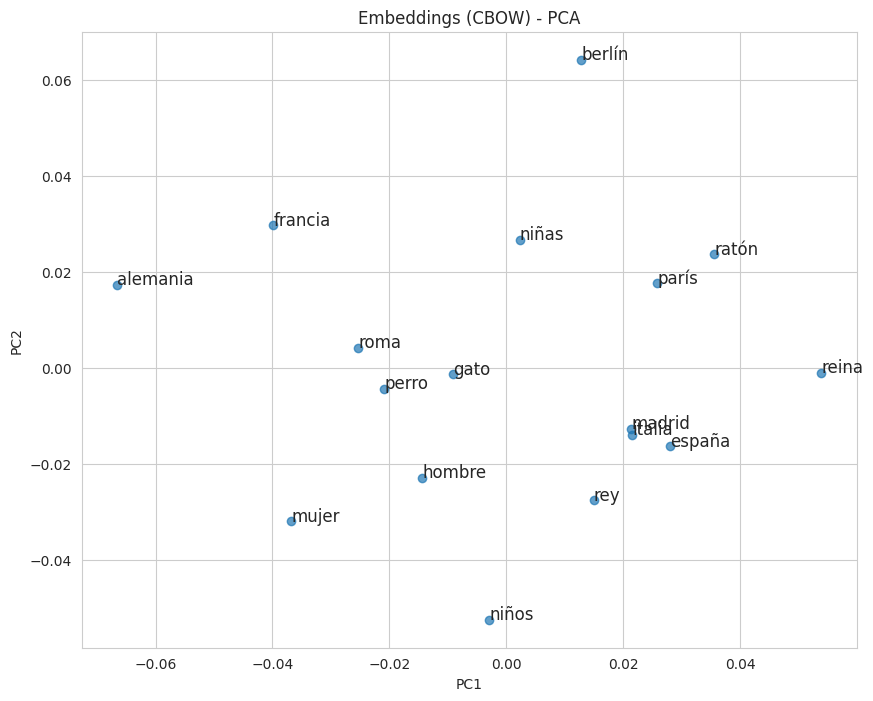

In [9]:
def plot_embeddings_pca(model, words, title):
    """Visualiza embeddings usando PCA."""
    # Obtener vectores de las palabras
    word_vectors = np.array([model.wv[word] for word in words if word in model.wv])
    words_present = [word for word in words if word in model.wv]

    # Aplicar PCA
    pca = PCA(n_components=2)
    vectors_pca = pca.fit_transform(word_vectors)

    # Graficar
    plt.figure(figsize=(10, 8))
    plt.scatter(vectors_pca[:, 0], vectors_pca[:, 1], alpha=0.7)
    for i, word in enumerate(words_present):
        plt.annotate(word, (vectors_pca[i, 0], vectors_pca[i, 1]), fontsize=12)
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
    plt.show()

# Palabras de interés
words_of_interest = ['rey', 'reina', 'hombre', 'mujer', 'niños', 'niñas',
                     'perro', 'gato', 'ratón', 'madrid', 'parís', 'roma', 'berlín',
                     'españa', 'francia', 'italia', 'alemania']

plot_embeddings_pca(model_cbow, words_of_interest, "Embeddings (CBOW) - PCA")

### 4.1. Visualización con t-SNE

t-SNE es mejor para visualizar estructuras locales.

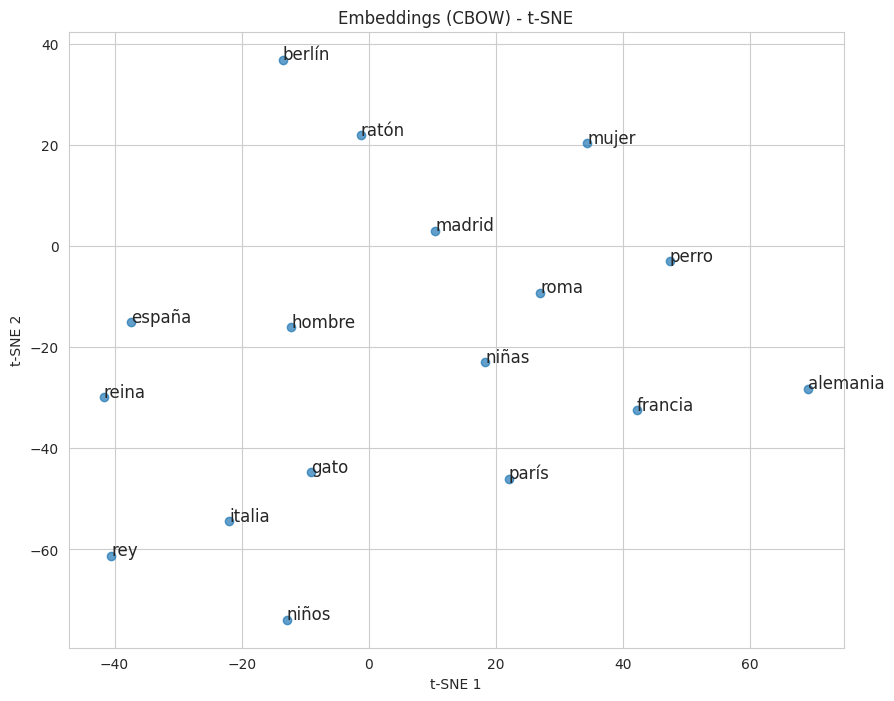

In [10]:
def plot_embeddings_tsne(model, words, title):
    """Visualiza embeddings usando t-SNE."""
    # Obtener vectores de las palabras
    word_vectors = np.array([model.wv[word] for word in words if word in model.wv])
    words_present = [word for word in words if word in model.wv]

    # Aplicar t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    vectors_tsne = tsne.fit_transform(word_vectors)

    # Graficar
    plt.figure(figsize=(10, 8))
    plt.scatter(vectors_tsne[:, 0], vectors_tsne[:, 1], alpha=0.7)
    for i, word in enumerate(words_present):
        plt.annotate(word, (vectors_tsne[i, 0], vectors_tsne[i, 1]), fontsize=12)
    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid(True)
    plt.show()

plot_embeddings_tsne(model_cbow, words_of_interest, "Embeddings (CBOW) - t-SNE")

---
## 5. Prueba de Analogías

Probamos la famosa analogía: rey - hombre + mujer = reina

In [11]:
def test_analogy(model, word1, word2, word3, topn=5):
    """Prueba analogía: word1 - word2 + word3"""
    try:
        result = model.wv.most_similar(positive=[word1, word3], negative=[word2], topn=topn)
        print(f"{word1} - {word2} + {word3}:")
        for word, score in result:
            print(f"  {word}: {score:.4f}")
        return result
    except KeyError as e:
        print(f"Palabra no encontrada: {e}")
        return None

print("=== Analogías con CBOW ===")
test_analogy(model_cbow, 'rey', 'hombre', 'mujer')

print("\n=== Analogías con Skip-gram ===")
test_analogy(model_skipgram, 'rey', 'hombre', 'mujer')

# Otras analogías
print("\n=== Capitales ===")
test_analogy(model_cbow, 'españa', 'madrid', 'francia')  # debería dar parís
test_analogy(model_cbow, 'francia', 'parís', 'italia')    # debería dar roma

=== Analogías con CBOW ===
rey - hombre + mujer:
  gobierna: 0.3459
  los: 0.3232
  camina: 0.3225
  el: 0.2286
  las: 0.1768

=== Analogías con Skip-gram ===
rey - hombre + mujer:
  gobierna: 0.3458
  los: 0.3232
  camina: 0.3226
  el: 0.2288
  las: 0.1769

=== Capitales ===
españa - madrid + francia:
  capital: 0.3142
  por: 0.2303
  al: 0.2230
  reino: 0.2039
  de: 0.1706
francia - parís + italia:
  alemania: 0.3708
  de: 0.2799
  por: 0.2591
  en: 0.2201
  el: 0.1948


[('alemania', 0.370750367641449),
 ('de', 0.2798703908920288),
 ('por', 0.25914743542671204),
 ('en', 0.22013933956623077),
 ('el', 0.19477379322052002)]

---
## 6. Embeddings Pre-entrenados de GloVe

Cargamos embeddings de GloVe (versión pequeña de 50 dimensiones) para explorar similitudes y comparar cobertura.

In [12]:
# Función para descargar GloVe (versión pequeña)
def download_glove():
    if not os.path.exists('glove.6B.50d.txt'):
        print("Descargando GloVe 6B (50d)...")
        url = 'https://nlp.stanford.edu/data/glove.6B.zip'
        urllib.request.urlretrieve(url, 'glove.6B.zip')
        with zipfile.ZipFile('glove.6B.zip', 'r') as zip_ref:
            zip_ref.extract('glove.6B.50d.txt')
        print("Descarga completada.")
    else:
        print("Archivo GloVe ya existe.")

# Descargar si no existe
download_glove()

# Cargar GloVe como KeyedVectors
print("\nCargando embeddings GloVe...")
glove_model = KeyedVectors.load_word2vec_format('glove.6B.50d.txt', no_header=True)
print("GloVe cargado.")

Descargando GloVe 6B (50d)...
Descarga completada.

Cargando embeddings GloVe...
GloVe cargado.


### 6.1. Exploración de GloVe

In [13]:
# Palabras similares con GloVe
print("Palabras similares a 'king' en GloVe:")
sim_glove = glove_model.most_similar('king', topn=5)
for word, score in sim_glove:
    print(f"  {word}: {score:.4f}")

# Analogía con GloVe
print("\nAnalogía: king - man + woman")
result_glove = glove_model.most_similar(positive=['woman', 'king'], negative=['man'], topn=3)
for word, score in result_glove:
    print(f"  {word}: {score:.4f}")

Palabras similares a 'king' en GloVe:
  prince: 0.8236
  queen: 0.7839
  ii: 0.7746
  emperor: 0.7736
  son: 0.7667

Analogía: king - man + woman
  queen: 0.8524
  throne: 0.7664
  prince: 0.7592


---
## 7. Comparación de Cobertura de Vocabulario

Comparamos qué palabras de nuestro corpus están presentes en cada modelo.

In [14]:
# Palabras de nuestro corpus
all_words = set([word for tokens in tokenized_corpus for word in tokens])
print(f"Total de palabras en corpus: {len(all_words)}")
print(all_words)

# Cobertura en Word2Vec propio
words_in_cbow = set(model_cbow.wv.key_to_index.keys())
coverage_cbow = len(all_words.intersection(words_in_cbow)) / len(all_words)
print(f"\nCobertura en Word2Vec (CBOW): {coverage_cbow:.2%}")

# Cobertura en GloVe
words_in_glove = set(glove_model.key_to_index.keys())
coverage_glove = len(all_words.intersection(words_in_glove)) / len(all_words)
print(f"Cobertura en GloVe: {coverage_glove:.2%}")

# Palabras no encontradas en GloVe
missing = all_words - words_in_glove
if missing:
    print(f"\nPalabras no encontradas en GloVe: {missing}")

Total de palabras en corpus: 34
{'ratón', 'por', 'calle', 'los', 'el', 'niños', 'niñas', 'alemania', 'madrid', 'francia', 'la', 'capital', 'roma', 'españa', 'mujer', 'hombre', 'juegan', 'perro', 'rey', 'reino', 'persigue', 'al', 'parque', 'italia', 'berlín', 'de', 'camina', 'gobierna', 'es', 'parís', 'las', 'gato', 'en', 'reina'}

Cobertura en Word2Vec (CBOW): 100.00%
Cobertura en GloVe: 82.35%

Palabras no encontradas en GloVe: {'juegan', 'niñas', 'persigue', 'berlín', 'camina', 'gobierna'}


---
## 8. Experimentación Adicional

### 8.1. Comparación de similitudes entre modelos

In [15]:
# Seleccionamos algunas palabras para comparar similitudes
test_words = ['rey', 'reina', 'hombre', 'mujer', 'españa', 'madrid']

print("=== Comparación de similitudes ===\n")
for word in test_words:
    print(f"\nPalabra: '{word}'")
    print("  CBOW:")
    if word in model_cbow.wv:
        sim_cbow = model_cbow.wv.most_similar(word, topn=3)
        for w, s in sim_cbow:
            print(f"    {w}: {s:.4f}")

    print("  GloVe:")
    if word in glove_model:
        sim_glove = glove_model.most_similar(word, topn=3)
        for w, s in sim_glove:
            print(f"    {w}: {s:.4f}")

=== Comparación de similitudes ===


Palabra: 'rey'
  CBOW:
    italia: 0.2300
    el: 0.1966
    las: 0.1887
  GloVe:
    bellet: 0.7685
    rafael: 0.7288
    del: 0.7282

Palabra: 'reina'
  CBOW:
    españa: 0.3276
    italia: 0.3156
    en: 0.3043
  GloVe:
    pepe: 0.7545
    carvalho: 0.7505
    oliveira: 0.7495

Palabra: 'hombre'
  CBOW:
    juegan: 0.2755
    españa: 0.2001
    gato: 0.1593
  GloVe:
    ese: 0.8041
    siempre: 0.7888
    fuera: 0.7828

Palabra: 'mujer'
  CBOW:
    los: 0.3270
    parque: 0.3085
    gobierna: 0.1479
  GloVe:
    voz: 0.7931
    una: 0.7918
    vida: 0.7882

Palabra: 'españa'
  CBOW:
    reina: 0.3276
    en: 0.2493
    hombre: 0.2001
  GloVe:
    vuelta: 0.7535
    américa: 0.7269
    supercopa: 0.7249

Palabra: 'madrid'
  CBOW:
    reina: 0.2606
    es: 0.2047
    ratón: 0.1935
  GloVe:
    milan: 0.8963
    barcelona: 0.8911
    valencia: 0.8619


---
## 9. Conclusiones

En este notebook hemos explorado los fundamentos de los word embeddings:

✔️ **Arquitecturas**:
- CBOW: predice la palabra objetivo desde el contexto (rápido, bueno para palabras frecuentes).
- Skip-gram: predice el contexto desde la palabra objetivo (mejor para palabras raras y analogías).

✔️ **Entrenamiento con gensim**:
- Entrenamos embeddings sobre un corpus pequeño.
- Exploramos palabras similares.

✔️ **Visualización**:
- PCA y t-SNE muestran agrupaciones semánticas (rey/reina, países/capitales).

✔️ **Analogías**:
- Probamos la relación rey - hombre + mujer ≈ reina.
- Con corpus pequeño, las analogías pueden no ser perfectas.

✔️ **GloVe**:
- Cargamos embeddings pre-entrenados con mucha mayor cobertura.
- Las analogías funcionan mucho mejor.
- GloVe captura relaciones semánticas globales.

**Lección clave**: Los embeddings densos capturan relaciones semánticas que las representaciones dispersas no pueden. Son la base de modelos más avanzados como BERT y GPT.

En el próximo notebook (NB2) aplicaremos estos conceptos a un problema real de búsqueda de similitudes.

---
**Fin del Notebook Conceptual - Semana 4 (NLP)**